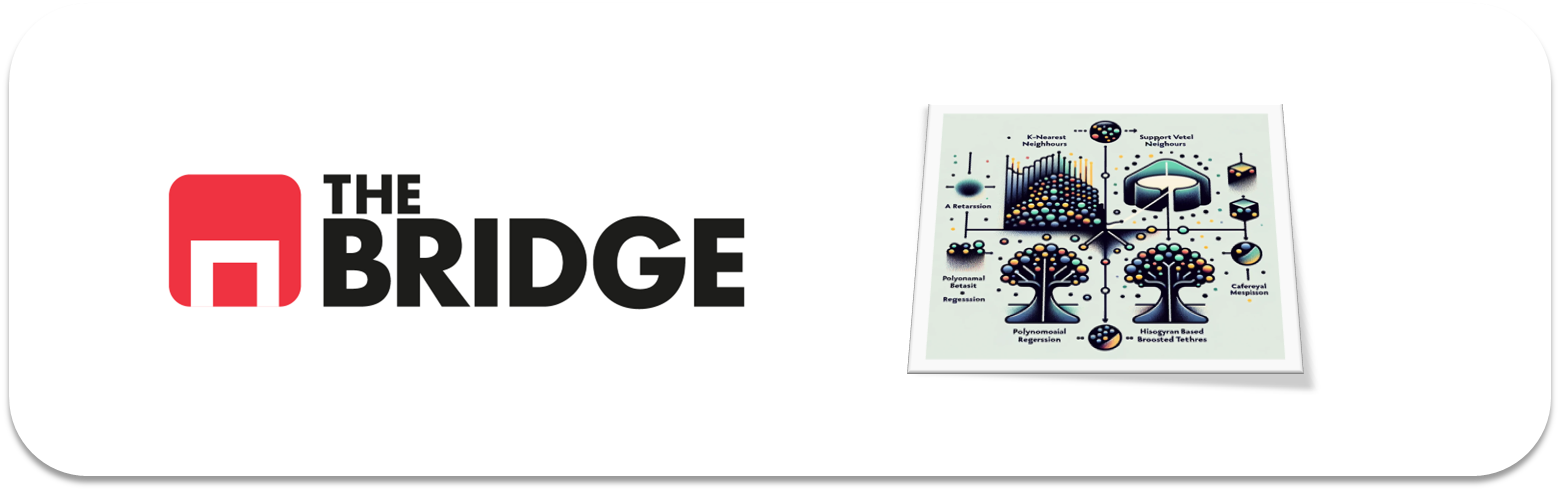

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

from imblearn.over_sampling import SMOTE 
from imblearn.under_sampling import RandomUnderSampler 
from sklearn.utils import resample

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
pd.options.mode.copy_on_write = True

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [3]:
def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB


In [5]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
fixed acidity,float64,0.0,106,1.63
volatile acidity,float64,0.0,187,2.88
citric acid,float64,0.0,89,1.37
residual sugar,float64,0.0,316,4.86
chlorides,float64,0.0,214,3.29
free sulfur dioxide,float64,0.0,135,2.08
total sulfur dioxide,float64,0.0,276,4.25
density,float64,0.0,998,15.36
pH,float64,0.0,108,1.66
sulphates,float64,0.0,111,1.71


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
from bootcampviztools import pinta_distribucion_categoricas, plot_combined_graphs

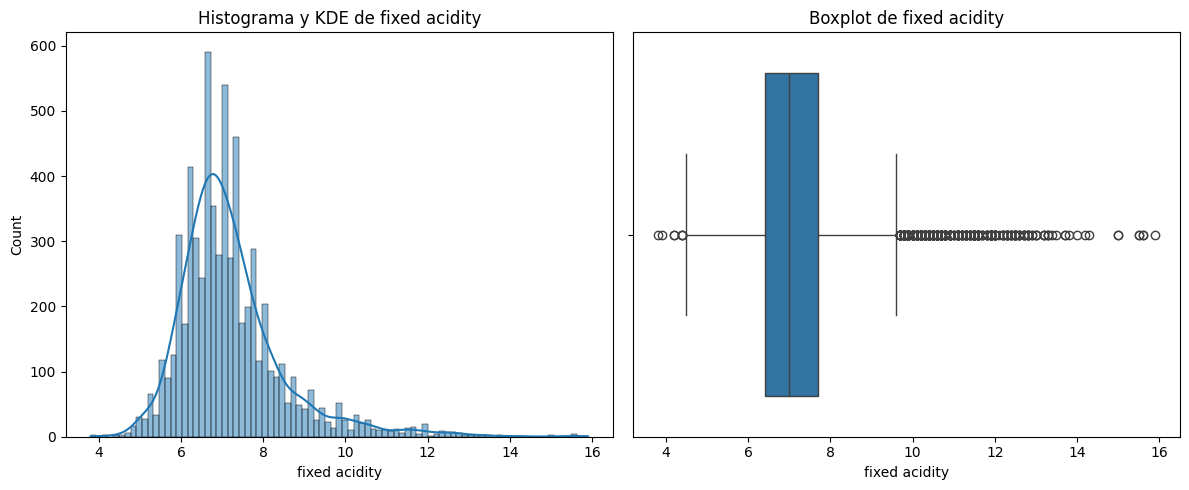

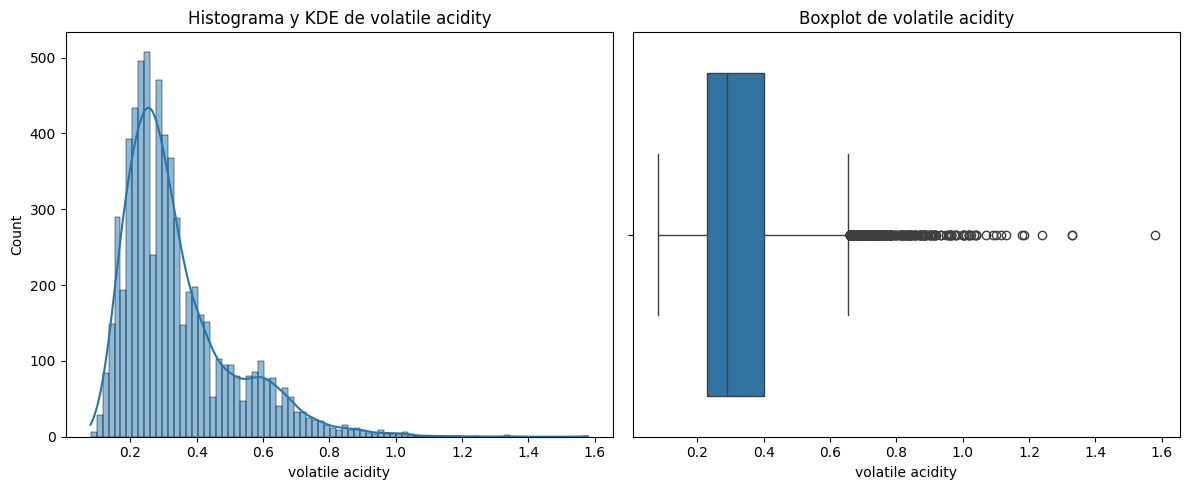

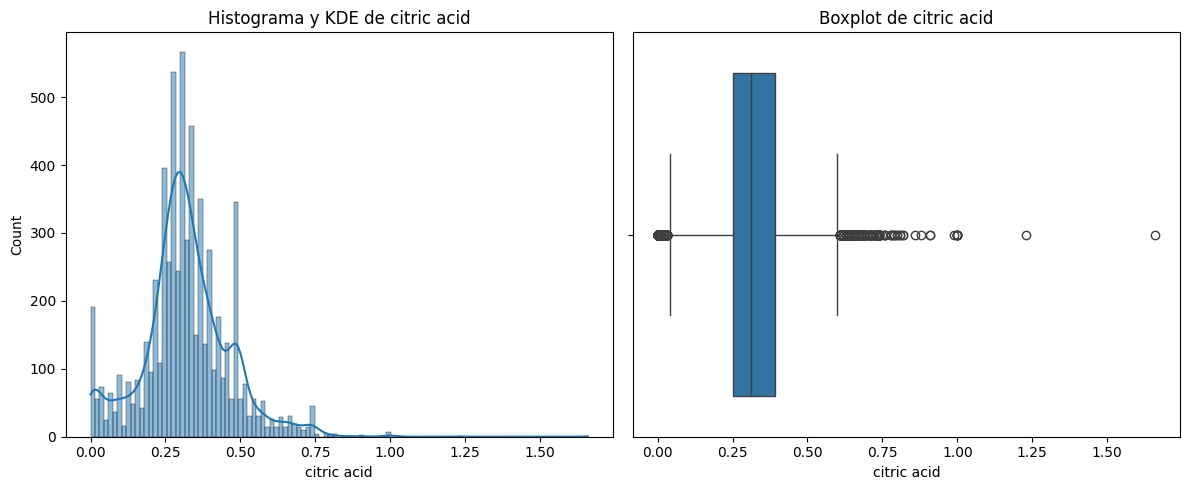

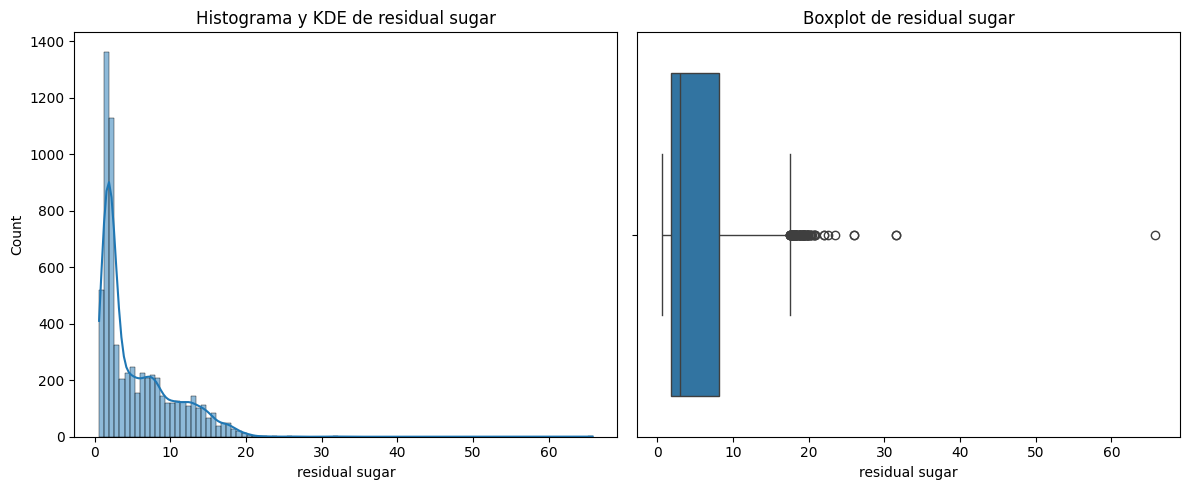

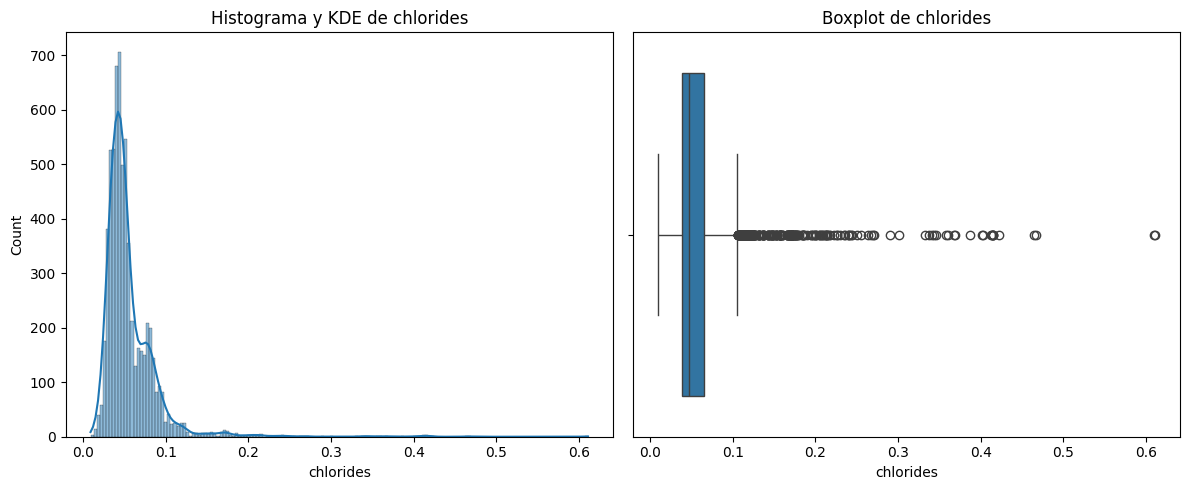

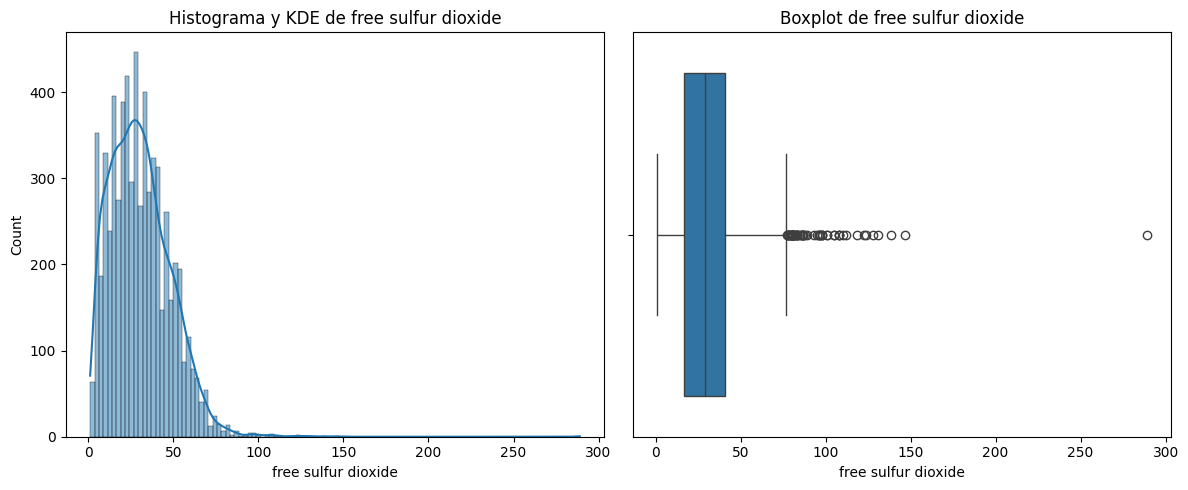

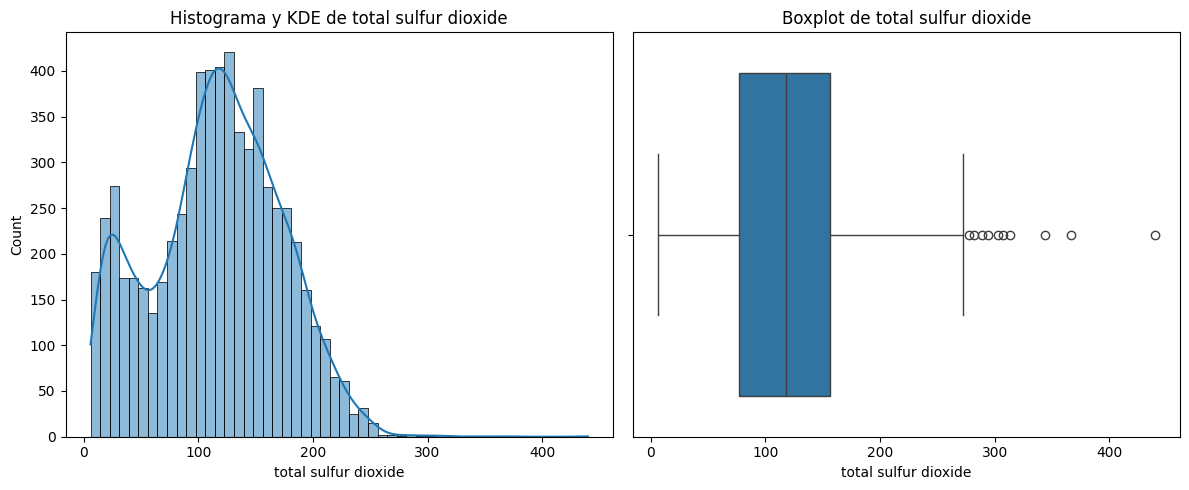

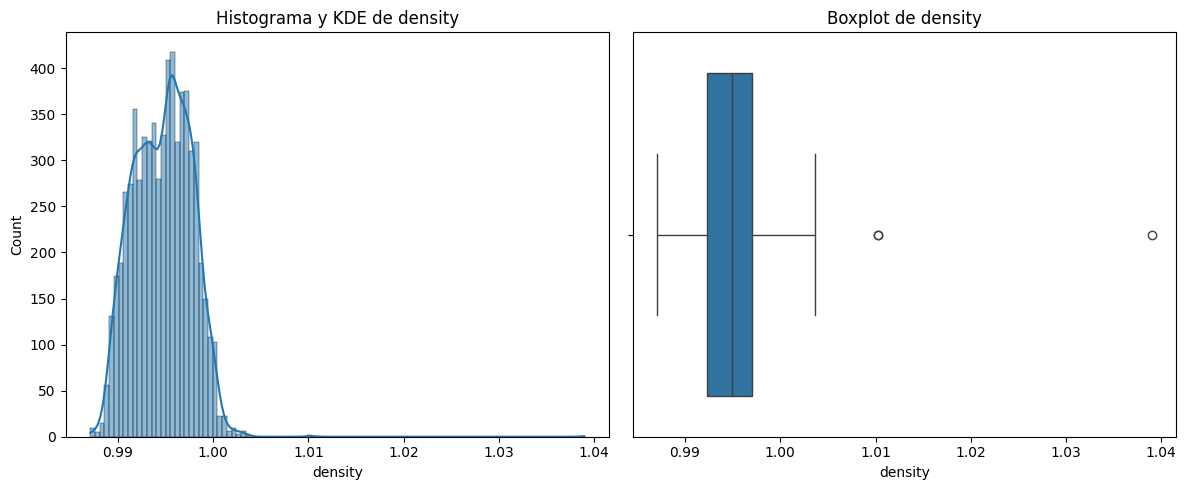

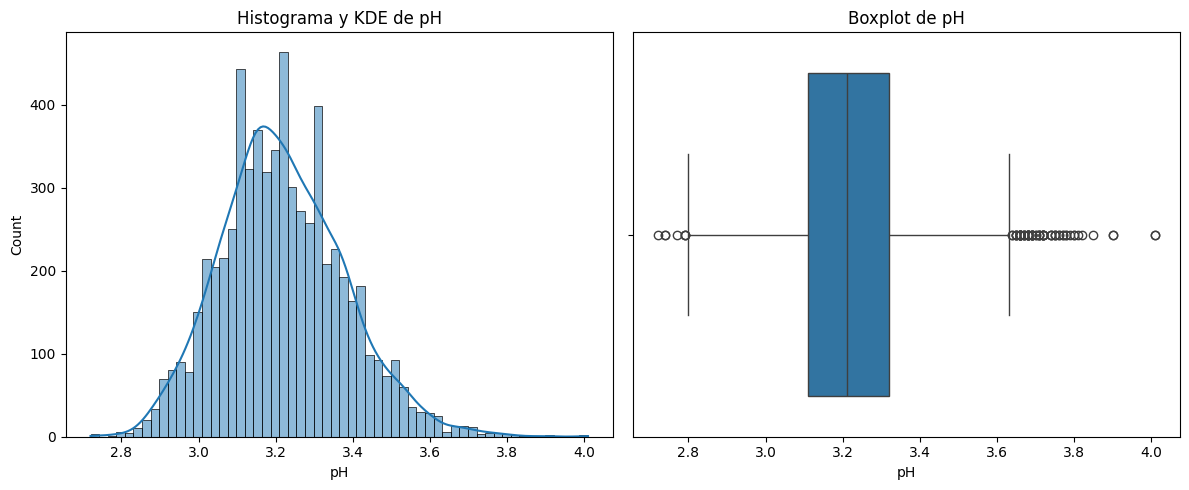

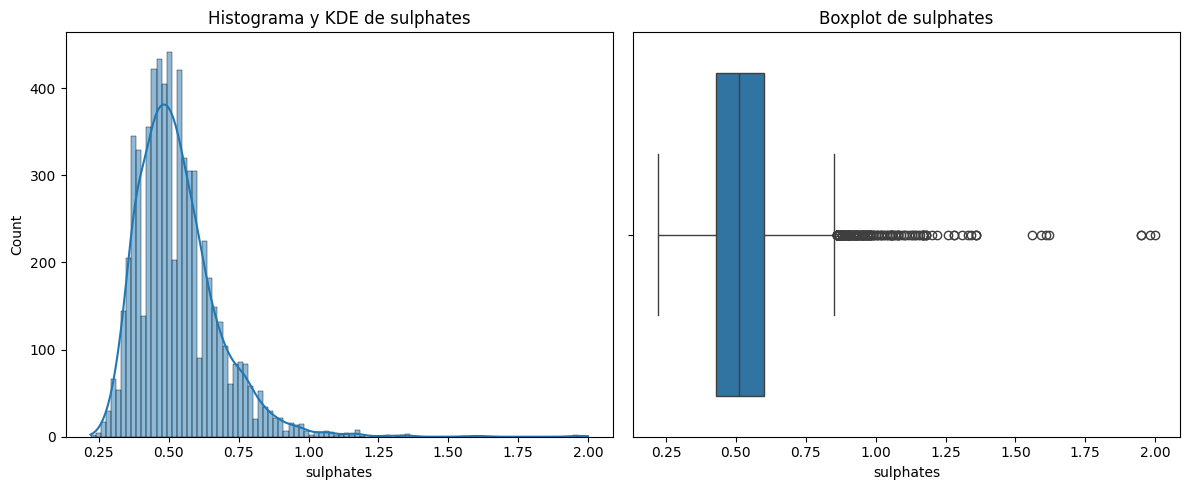

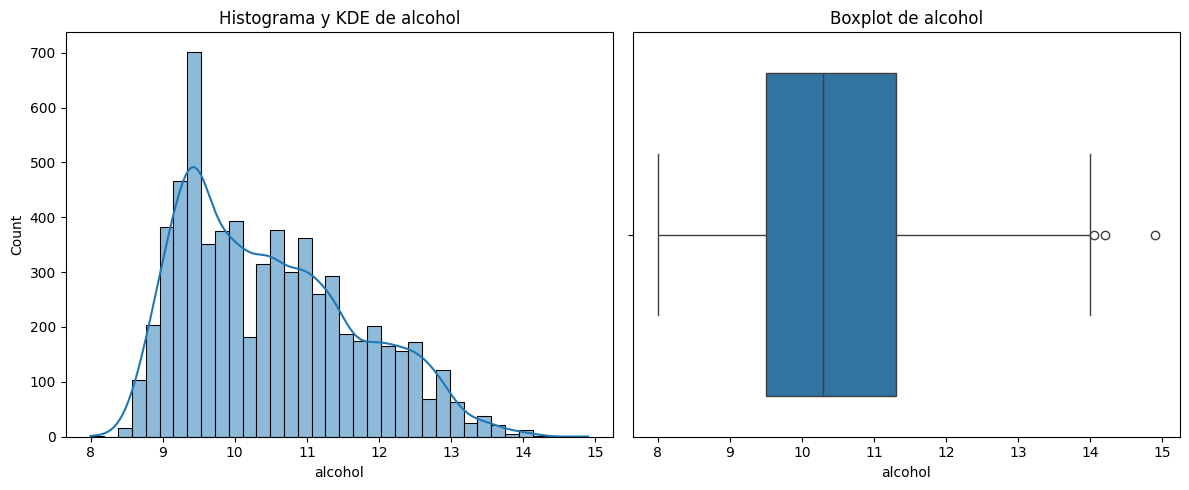

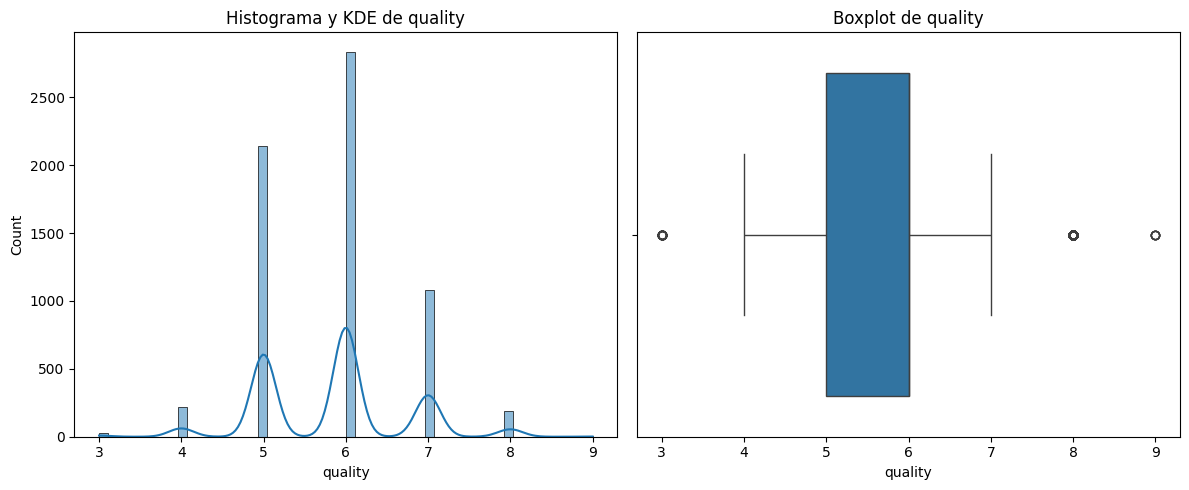

In [7]:
features_num = df.select_dtypes(include="number").columns

for feature in features_num:
    plot_combined_graphs(df, [feature])

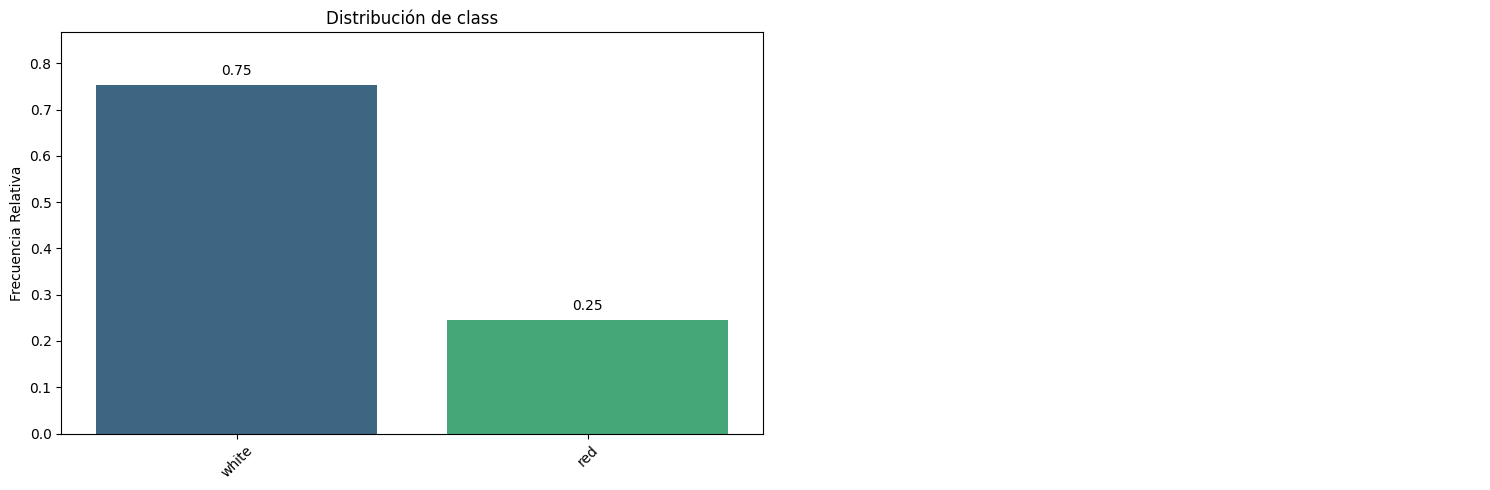

In [8]:
pinta_distribucion_categoricas(
    df,
    columnas_categoricas=["class"],
    relativa=True,
    mostrar_valores=True
)

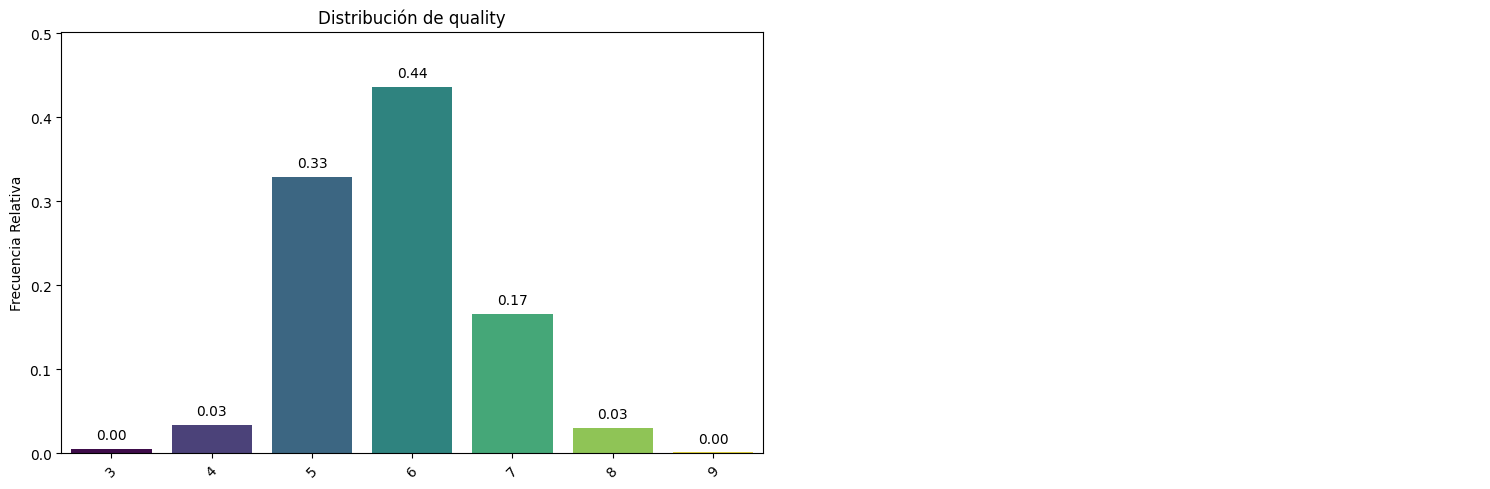

In [9]:
pinta_distribucion_categoricas(
    df,
    columnas_categoricas=["quality"],
    relativa=True,
    mostrar_valores=True
)

In [10]:
# Eliminamos los duplicados
df.duplicated().sum()

np.int64(1177)

In [11]:
df = df.drop_duplicates()

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [12]:
TARGET = 'quality'  # ← Cambia esto por el nombre de tu columna objetivo

n_unique = df[TARGET].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET].describe())

Valores únicos en la target: 7
→ Posible CLASIFICACIÓN
quality
6    2323
5    1752
7     856
4     206
8     148
3      30
9       5
Name: count, dtype: int64


In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y         # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 4256 filas  (80 %)
Test:  1064 filas  (20 %)


In [14]:
features_num = features_num.drop("quality")
features_num

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='str')

                 feature  importance
10               alcohol   12.638908
7                density   10.242461
1       volatile acidity    9.728129
6   total sulfur dioxide    9.122313
9              sulphates    8.741233
5    free sulfur dioxide    8.724598
4              chlorides    8.680660
8                     pH    8.446844
3         residual sugar    8.421500
2            citric acid    7.787803
0          fixed acidity    7.465551


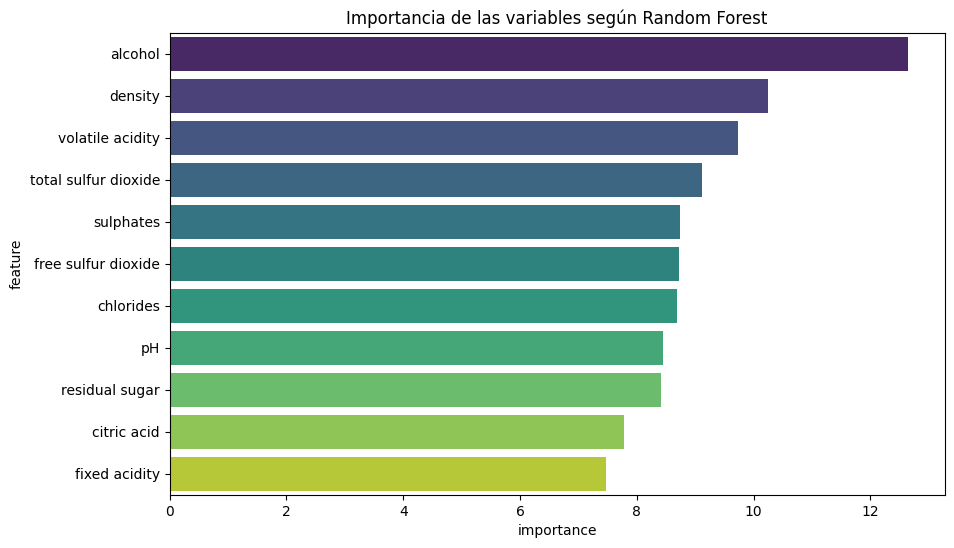

In [15]:
# IMPORTANCIA DE LAS FEATURES CON RANDOM FOREST

# 1. Crear un DataFrame solo con las columnas numéricas
X_num = df.select_dtypes(include="number")

# 2. Separar X e y usando tu TARGET
y = df["quality"]
X = X_num.drop(columns=["quality"])

# 3. Entrenar Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# 4. Importancia de las features
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importances["importance"] = importances["importance"] * 100
print(importances)

# 5. Visualización
plt.figure(figsize=(10,6))
sns.barplot(data=importances, x="importance", y="feature", palette="viridis")
plt.title("Importancia de las variables según Random Forest")
plt.show()


In [16]:
# IMPORTANCIA DE LAS FEATURES NUM CON ANOVA

from sklearn.feature_selection import f_classif
import pandas as pd

target = "quality"

# Seleccionamos solo numéricas excepto la target
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(target)

X = df[num_cols]
y = df[target]

F, p = f_classif(X, y)

anova_df = pd.DataFrame({
    "feature": num_cols,
    "F_value": F,
    "p_value": p
}).sort_values("p_value")

anova_df


,feature,F_value,p_value
10,alcohol,308.443395,0.000000e+00
7,density,130.402663,1.866345e-154
1,volatile acidity,80.682618,6.190343e-97
4,chlorides,43.354735,5.572227e-52
5,free sulfur dioxide,13.195808,6.884849e-15
3,residual sugar,10.318086,2.154395e-11
2,citric acid,9.512440,2.013273e-10
6,total sulfur dioxide,8.150598,8.568228e-09
0,fixed acidity,7.125690,1.400125e-07
9,sulphates,3.537085,1.697080e-03


In [16]:
from scipy import stats

def get_features_num_classification(df, target, pvalue_rango=0.05):
    """
    Selección de features numéricas relevantes para un modelo de 
    clasificación usando el método estadístico ANOVA.

    Parámetros:
        - df : DataFrame
        - target : str - Nombre de la columna objetivo.
        - pvalue_rango : float - Umbral de significancia (default=0.05).

    Retorna:
    --------
    features_num_sel : Lista de nombres de features numéricas seleccionadas.
    """
    # Separar X e y
    y = df[target]
    X = df.drop(columns=[target])

    # Seleccionar solo columnas numéricas
    features_num = X.select_dtypes(include=["int64", "float64"])

    # Si no hay columnas numéricas retorna una lista vacía
    if features_num.shape[1] == 0:
        return []

    # Creamos una lista vacía para que se guarden las features seleccionadas
    features_num_sel = []

    # Para cada columna numérica aplicamos el método y calculamos p_value
    for col in features_num.columns:

        # Crear lista de grupos: una lista por cada clase del target
        grupos = [df[df[target] == clase][col].dropna() 
                  for clase in df[target].unique()]

        # Método ANOVA
        f_val, p_val = stats.f_oneway(*grupos)

        # Seleccionar si p < umbral, se rechaza la hipótesis nula (la variable es dependiente)
        if p_val < pvalue_rango:
            features_num_sel.append(col)

    return features_num_sel

In [17]:
features_num_selec = get_features_num_classification(df, "quality")
features_num_selec

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [19]:
from scipy.stats import chi2_contingency

def get_features_cat_classification(df, target, pvalue_rango=0.05):
    """
    Selección de features categórcias relevantes para un modelo de 
    clasificación usando el método estadístico Chi-cuadrado.

    Parámetros:
        - df : DataFrame
        - target : str - Nombre de la columna objetivo.
        - pvalue_rango : float - Umbral de significancia (default=0.05).

    Retorna:
    --------
    features_cat_sel : Lista de nombres de features numéricas seleccionadas.
    """
    # Separar X e y
    y = df[target]
    X = df.drop(columns=[target])
    # Convertir columnas string (StringDtype) a object para evitar errores con SciPy
    X = X.astype({col: "object" for col in X.select_dtypes(include="string").columns})

    # Seleccionar solo columnas categóricas
    features_cat = X.select_dtypes(include=["object", "category"])

    # Si no hay columnas numéricas retorna una lista vacía
    if features_cat.shape[1] == 0:
        return []

    # Creamos una lista vacía para que se guarden las features seleccionadas
    features_cat_sel = []

    # Para cada columna cat aplicamos el método y calculamos p_value
    for col in features_cat.columns:

        # Crear tabla de contingencia
        tabla_contingencia = pd.crosstab(df[col], df[target])

        # Test Chi-cuadrado
        chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia)

        # Seleccionar si p < umbral, se rechaza la hipótesis nula (la variable es dependiente)
        if p_val < pvalue_rango:
            features_cat_sel.append(col)

    return features_cat_sel

In [20]:
features_cat_selec = get_features_cat_classification (df, "quality")
features_cat_selec

['class']

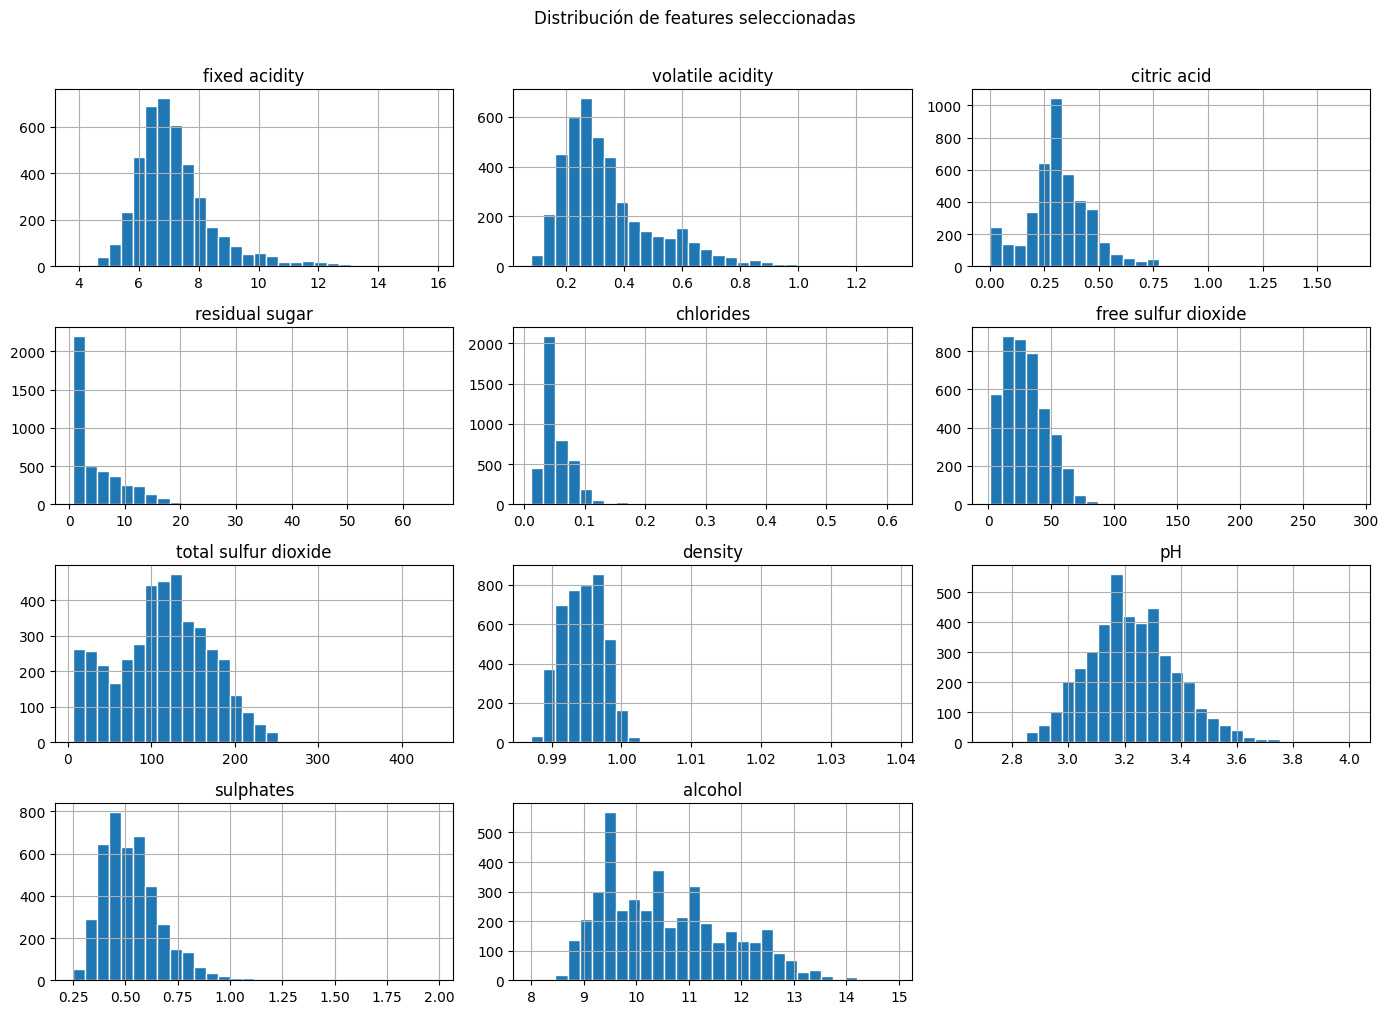

Skewness por feature seleccionada:
chlorides               5.052254
residual sugar          1.799819
sulphates               1.698652
fixed acidity           1.616090
free sulfur dioxide     1.495935
volatile acidity        1.407704
density                 0.809032
alcohol                 0.544261
citric acid             0.499989
pH                      0.372284
total sulfur dioxide    0.059595


In [21]:
# Mostramos un histograma de las features numéricas seleccionadas
X_train[features_num_selec].hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features seleccionadas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica seleccionadas
skew = X_train[features_num_selec].skew().sort_values(key=abs, ascending=False)
print("Skewness por feature seleccionada:")
print(skew.to_string())

In [22]:
# Hacemos transformación y escalado a las features numéricas seleccionadas

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

features_log = ["chlorides", "residual sugar", "sulphates", "fixed acidity", "free sulfur dioxide", "volatile acidity"]
for col in features_log:
        X_train_scaled[col] = np.log(X_train_scaled[col] + 1) # A todas les aplico log(x+1) porque tienen ceros
        X_test_scaled[col] = np.log(X_test_scaled[col] + 1) # A test le tengo que aplicar las mismas transformaciones que a train

features_sqrt = ["density", "alcohol", "citric acid"]
for col in features_sqrt:
        X_train_scaled[col] = np.sqrt(X_train_scaled[col])
        X_test_scaled[col] = np.sqrt(X_test_scaled[col])

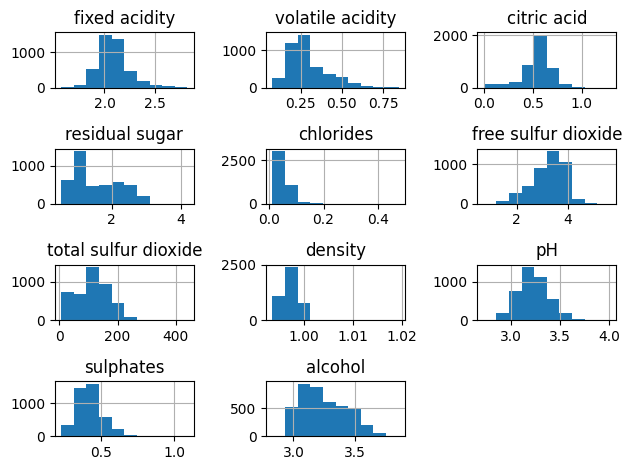

In [23]:
# Mostramos un histograma de las features numéricas ya transformadas
X_train_scaled[features_num].hist()
plt.tight_layout()

In [24]:
# RobustScaler alternativa para KNN
# from sklearn.preprocessing import RobustScale

# Escalamos las features numéricas
scaler = StandardScaler()

X_train_scaled[features_num] = scaler.fit_transform(X_train_scaled[features_num])
X_test_scaled[features_num] = scaler.transform(X_test_scaled[features_num])

In [25]:
# Comprobamos el escalado 
X_train_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03,4.256000e+03
mean,-1.572677e-15,1.961672e-16,4.879138e-16,1.085180e-16,8.848394e-17,3.339017e-16,1.335607e-17,-6.357195e-14,9.599673e-16,-6.932633e-16,1.168656e-16
std,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00
min,-3.550248e+00,-1.823587e+00,-3.447385e+00,-1.568745e+00,-1.336937e+00,-3.851865e+00,-1.904280e+00,-2.484486e+00,-3.160940e+00,-2.169046e+00,-2.291561e+00
25%,-6.304046e-01,-7.093164e-01,-3.294838e-01,-8.131829e-01,-5.436500e-01,-6.129834e-01,-7.025949e-01,-7.865548e-01,-6.552783e-01,-7.106553e-01,-8.933568e-01
50%,-1.045225e-01,-2.350871e-01,9.615688e-02,-3.911608e-01,-2.736731e-01,1.953234e-01,3.962255e-02,5.076262e-02,-2.886280e-02,-1.205468e-01,-1.071704e-01
75%,4.612920e-01,4.608373e-01,5.778081e-01,8.682326e-01,3.180593e-01,7.558654e-01,6.934808e-01,7.543960e-01,6.601943e-01,5.070567e-01,7.274414e-01
max,4.940177e+00,4.764267e+00,4.752557e+00,3.989921e+00,1.320230e+01,3.680169e+00,5.765300e+00,1.468625e+01,4.919820e+00,7.249018e+00,3.392192e+00


In [26]:
# Realizamos el OneHotEncoder para "class" - get_dummies
X_train = pd.get_dummies(X_train, columns=["class"], drop_first=False, dtype=int)
X_test = pd.get_dummies(X_test, columns=["class"], drop_first=False, dtype=int)

# Lo aplicamos tambien ha X_train_scaled y X_test_scaled
X_train_scaled = pd.get_dummies(X_train_scaled, columns=["class"], drop_first=False, dtype=int)
X_test_scaled = pd.get_dummies(X_test_scaled, columns=["class"], drop_first=False, dtype=int)

# Asegurar que test tiene las mismas columnas que train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
X_test_scaled = X_test_scaled.reindex(columns=X_train_scaled.columns, fill_value=0)


In [27]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,class_red,class_white
675,7.1,0.31,0.25,11.2,0.048,32.0,136.0,0.99663,3.14,0.40,9.5,0,1
3310,7.3,0.23,0.41,14.6,0.048,73.0,223.0,0.99863,3.16,0.71,9.4,0,1
3739,6.4,0.26,0.21,7.1,0.040,35.0,162.0,0.99560,3.39,0.58,9.9,0,1
3123,6.3,0.30,0.48,1.8,0.069,18.0,61.0,0.99590,3.44,0.78,10.3,1,0
3899,8.4,0.20,0.27,6.3,0.048,30.0,143.0,0.99660,3.25,0.50,9.1,0,1


In [28]:
# baseline para KNN, utilizamos X_train_scaled

knn_clf = KNeighborsClassifier(n_neighbors= 3) # n_neighbors = siempre impar

knn_clf.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [29]:
# Probamos el modelo frente a Train
print(classification_report(y_train, knn_clf.predict(X_train_scaled)))

              precision    recall  f1-score   support

           3       0.47      0.58      0.52        24
           4       0.53      0.68      0.60       165
           5       0.73      0.80      0.77      1402
           6       0.76      0.78      0.77      1858
           7       0.74      0.60      0.66       685
           8       0.71      0.20      0.32       118
           9       0.00      0.00      0.00         4

    accuracy                           0.73      4256
   macro avg       0.56      0.52      0.52      4256
weighted avg       0.73      0.73      0.73      4256



In [30]:
# baseline para KNN, utilizamos X_train_scaled

knn_clf = KNeighborsClassifier(n_neighbors= 5) # n_neighbors = siempre impar

knn_clf.fit(X_train_scaled, y_train)

print(classification_report(y_train, knn_clf.predict(X_train_scaled)))


              precision    recall  f1-score   support

           3       0.60      0.12      0.21        24
           4       0.56      0.37      0.45       165
           5       0.69      0.76      0.72      1402
           6       0.67      0.75      0.71      1858
           7       0.66      0.49      0.56       685
           8       0.33      0.04      0.08       118
           9       1.00      0.25      0.40         4

    accuracy                           0.67      4256
   macro avg       0.64      0.40      0.45      4256
weighted avg       0.66      0.67      0.66      4256



In [31]:
# baseline para KNN, utilizamos X_train_scaled

knn_clf = KNeighborsClassifier(n_neighbors= 7) # n_neighbors = siempre impar

knn_clf.fit(X_train_scaled, y_train)

print(classification_report(y_train, knn_clf.predict(X_train_scaled)))


              precision    recall  f1-score   support

           3       0.67      0.08      0.15        24
           4       0.62      0.24      0.35       165
           5       0.67      0.75      0.71      1402
           6       0.65      0.73      0.69      1858
           7       0.60      0.45      0.51       685
           8       0.40      0.03      0.06       118
           9       0.00      0.00      0.00         4

    accuracy                           0.65      4256
   macro avg       0.52      0.33      0.35      4256
weighted avg       0.64      0.65      0.63      4256



In [31]:
from catboost import CatBoostClassifier

In [32]:
modelos = ["KNN", "Logistic", "RandomF", "CatBoost", "LightGBM"]
metricas = []

# Modelos base
knn = KNeighborsClassifier(n_neighbors=3)
lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)

cat_clf = CatBoostClassifier(
    depth=5,
    learning_rate=0.1,
    iterations=300,
    loss_function="MultiClass",
    verbose=0,
    random_seed=42
)

lgb_clf = LGBMClassifier(
    max_depth=5,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

# Comparación con validación cruzada
for nombre, modelo in zip(modelos, [knn, lr_clf, rf_clf, cat_clf, lgb_clf]):
    print(f"Para {nombre}:", end=" ")
    metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring="recall_macro"))
    print(metrica)
    metricas.append(metrica)


Para KNN: 0.2616031663362052
Para Logistic: 0.23488645581379144
Para RandomF: 0.2115439453051397
Para CatBoost: 0.25377388618560665
Para LightGBM: 0.2507536274784902


In [33]:
# Aplicamos oversampling (smote) para balancear las clases y volver a comprobar los modelos

smote = SMOTE(random_state=42, k_neighbors=3)

# Para modelos de árbol (RF, XGBoost, LightGBM): SMOTE en el espacio original.
# Los árboles no dependen de distancias entre features, así que la escala no importa.

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Para KNN y Regresión Logística: SMOTE en el espacio escalado.
# SMOTE usa distancias KNN internamente para generar sintéticos —
# aplicarlo en el espacio normalizado garantiza que todas las features
# contribuyen proporcionalmente y los sintéticos son coherentes con el modelo.
X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(X_train_scaled, y_train)

In [34]:
print(len(y_train))
print(len(y_train_smote))

4256
13006


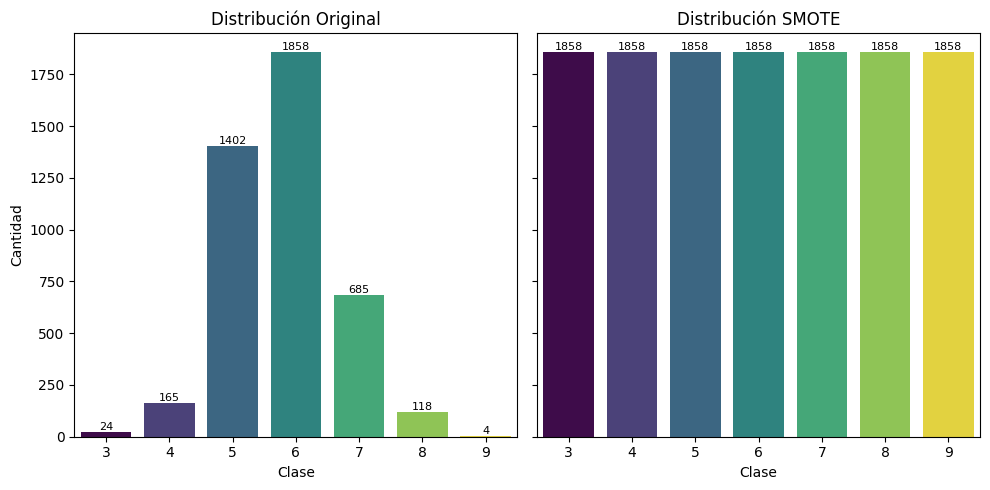

In [35]:
original_counts = y_train.value_counts()
smote_counts = y_train_smote.value_counts()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
primera = ax[0]
segunda = ax[1]

barplot_original = sns.barplot(x=original_counts.index, y=original_counts.values, ax=primera, palette='viridis', hue = original_counts.index, legend=False)
primera.set_title('Distribución Original')
primera.set_xlabel('Clase')
primera.set_ylabel('Cantidad')

for bar in barplot_original.patches:
    primera.annotate(f'{int(bar.get_height())}', 
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                     ha='center', va='bottom', fontsize=8)


barplot_smote = sns.barplot(x=smote_counts.index, y=smote_counts.values, ax=segunda, palette='viridis', hue = smote_counts.index, legend=False)
segunda.set_title('Distribución SMOTE')
segunda.set_xlabel('Clase')

for bar in barplot_smote.patches:
    segunda.annotate(f'{int(bar.get_height())}', 
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                     ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
modelos = ["KNN", "Logistic", "RandomF", "CatBoost", "LightGBM"]
metricas_smote = []

# Comparación con validación cruzada usando SMOTE
for nombre, modelo in zip(modelos, [knn, lr_clf, rf_clf, cat_clf, lgb_clf]):
    print(f"Para {nombre} con SMOTE:", end=" ")

    # Modelos basados en distancias → usar datos escalados + SMOTE escalado
    if nombre in ["KNN", "Logistic"]:
        X_bal = X_train_smote_scaled
        y_bal = y_train_smote_scaled
    else:
        # Modelos de árbol / boosting → usar SMOTE en datos sin escalar
        X_bal = X_train_smote
        y_bal = y_train_smote

    metrica = np.mean(cross_val_score(modelo, X_bal, y_bal, cv=5, scoring="recall_macro"))
    print(metrica)
    metricas_smote.append(metrica)


Para KNN con SMOTE: 0.8409301882652025
Para Logistic con SMOTE: 0.5391394537120997
Para RandomF con SMOTE: 0.5988009324240957
Para CatBoost con SMOTE: 0.7721117418361136
Para LightGBM con SMOTE: 0.8084822851843112


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Definición del espacio de búsqueda
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()

# GridSearch usando SMOTE + escalado
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

grid_knn.fit(X_train_smote_scaled, y_train_smote_scaled)

print("Mejores hiperparámetros:", grid_knn.best_params_)
print("Mejor recall_macro:", grid_knn.best_score_)


Mejores hiperparámetros: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Mejor recall_macro: 0.8619252570169882


              precision    recall  f1-score   support

           3       0.05      0.17      0.08         6
           4       0.12      0.24      0.16        41
           5       0.57      0.55      0.56       350
           6       0.55      0.39      0.46       465
           7       0.39      0.49      0.44       171
           8       0.12      0.30      0.18        30
           9       0.00      0.00      0.00         1

    accuracy                           0.45      1064
   macro avg       0.26      0.31      0.27      1064
weighted avg       0.50      0.45      0.47      1064



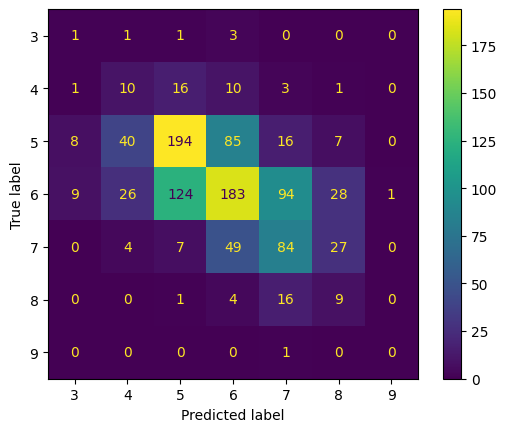

In [38]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

In [ ]:
# El modelo creado con SMOTE para KMM tiene un recall macro frente al train de 0.84, mientras que en test cae a un 0.31. El modelo genera mucha confusión entre las clases 5, 6 y 7.
# Una buena optimización sería crear un submodelo que diferencie esas 3 clases.

# un primer modelo que distinga entre el grupo {5, 6, 7} y el resto de clases, y
# un submodelo especializado entrenado únicamente para diferenciar entre las clases 5, 6 y 7

In [40]:
# LIGHTGBM

from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

param_dist = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, 15],
    "min_data_in_leaf": [10, 20, 50],
    "class_weight": ["balanced", None]
}

lgb_clf = LGBMClassifier(verbose=-1, random_state=42)

lgb_random = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_dist,
    n_iter=30,                 # número de combinaciones a probar (ajustable)
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
    random_state=42
)

lgb_random.fit(X_train_smote, y_train_smote)



KeyboardInterrupt: 

In [97]:
lgb_grid.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.5,
 'max_depth': 10,
 'min_data_in_leaf': 10,
 'n_estimators': 200}

In [98]:
lgb_grid.best_score_

np.float64(0.8530016023451378)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.18      0.15      0.16        41
           5       0.60      0.59      0.59       350
           6       0.55      0.60      0.57       465
           7       0.39      0.33      0.36       171
           8       0.21      0.13      0.16        30
           9       0.00      0.00      0.00         1

    accuracy                           0.52      1064
   macro avg       0.27      0.26      0.26      1064
weighted avg       0.51      0.52      0.51      1064



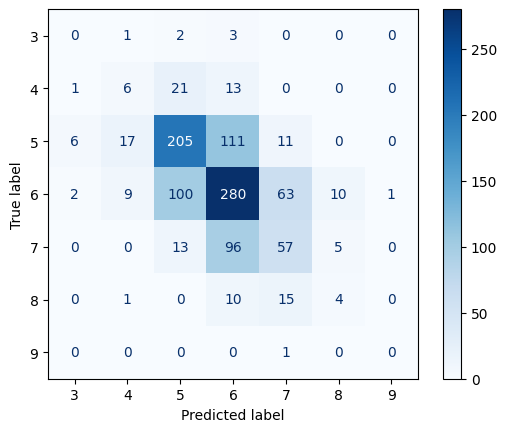

In [99]:
y_pred_lgb = lgb_grid.best_estimator_.predict(X_test)

print(classification_report(y_test, y_pred_lgb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgb, cmap="Blues")

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [55]:
TARGET_reg = 'alcohol' # ← Cambia esto por el nombre de tu columna objetivo

n_unique = df[TARGET_reg].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET_reg].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET_reg].describe())

Valores únicos en la target: 111
→ Posible REGRESIÓN
count    5320.000000
mean       10.549241
std         1.185933
min         8.000000
25%         9.500000
50%        10.400000
75%        11.400000
max        14.900000
Name: alcohol, dtype: float64


In [60]:
df.duplicated().sum()

np.int64(0)

In [57]:
X = df.drop(columns=[TARGET_reg])
y = df[TARGET_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    # stratify=y         # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train_reg: {X_train_reg.shape[0]} filas  ({X_train_reg.shape[0]/len(df)*100:.0f} %)")
print(f"Test_reg:  {X_test_reg.shape[0]} filas  ({X_test_reg.shape[0]/len(df)*100:.0f} %)")

Train_reg: 4256 filas  (80 %)
Test_reg:  1064 filas  (20 %)


In [58]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4256 entries, 675 to 3018
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4256 non-null   float64
 1   volatile acidity      4256 non-null   float64
 2   citric acid           4256 non-null   float64
 3   residual sugar        4256 non-null   float64
 4   chlorides             4256 non-null   float64
 5   free sulfur dioxide   4256 non-null   float64
 6   total sulfur dioxide  4256 non-null   float64
 7   density               4256 non-null   float64
 8   pH                    4256 non-null   float64
 9   sulphates             4256 non-null   float64
 10  alcohol               4256 non-null   float64
 11  class_red             4256 non-null   int64  
 12  class_white           4256 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 465.5 KB


In [62]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

def get_features_num_regression(
    df: pd.DataFrame,
    target_col: str,
    umbral_corr: float,
    metodo: str = "spearman",   # por defecto Spearman
    pvalue: float = 0.05        # por defecto 0.05
) -> list:
    """
    Selecciona columnas numéricas correlacionadas con el target usando Pearson o Spearman.

    Argumentos:
        df (pd.DataFrame): DataFrame con los datos.
        target_col (str): nombre de la columna objetivo.
        umbral_corr (float): umbral de correlación absoluta.
        metodo (str): 'pearson' o 'spearman'. Por defecto 'spearman'.
        pvalue (float): p-valor máximo permitido. Por defecto 0.05.

    Retorna:
        list: columnas numéricas relevantes.
    """

    if metodo not in ["pearson", "spearman"]:
        raise ValueError("metodo debe ser 'pearson' o 'spearman'")

    resultado = []
    columnas_numericas = df.select_dtypes(include=np.number).columns

    for col in columnas_numericas:
        if col == target_col:
            continue

        datos = df[[col, target_col]].dropna()

        if len(datos) < 2 or datos[col].nunique() < 2:
            continue

        # Selección del método
        if metodo == "pearson":
            r, p = pearsonr(datos[col], datos[target_col])
        else:
            r, p = spearmanr(datos[col], datos[target_col])

        # Filtros
        if abs(r) > umbral_corr and p < pvalue:
            resultado.append(col)

    return resultado


In [ ]:
features_relevantes = get_features_num_regression(df, TARGET_reg, umbral_corr=0.2, metodo="spearman")

print("Variables numéricas relevantes:", features_relevantes)


Variables numéricas relevantes: ['residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'quality']


In [68]:
df = pd.get_dummies(df, columns=['class'], drop_first=False, dtype=int)


KeyError: "None of [Index(['class'], dtype='str')] are in the [columns]"

In [67]:
TARGET_reg = "alcohol"

X = df[['residual sugar', 
        'chlorides', 
        'total sulfur dioxide', 
        'density', 
        'quality', 
        'class_red', 
        'class_white']]   # añades las categóricas

y = df[TARGET_reg]


KeyError: "['class_red'] not in index"